# Mini Project: Building a Robust Part-of-Speech (POS) Tagger
### Hidden Markov Model (HMM) built **from scratch** + Log-Space Viterbi

**Goal.** Given a sentence, decide for every word whether it is a `NOUN`, `VERB`,
`ADJ` (adjective), `ADV` (adverb), etc. We do **not** use any ready-made tagger.
We build the HMM by hand:

- **&pi;** &nbsp;initial probabilities &nbsp;&rarr; P(tag is the first word of a sentence)
- **A** &nbsp;transition probabilities &nbsp;&rarr; P(tag_j | tag_i)
- **B** &nbsp;emission probabilities &nbsp;&rarr; P(word | tag)

Then we decode the most likely tag sequence with the **Viterbi** algorithm,
rewritten in **log-space** so probabilities do not underflow on long sentences.

**Two engineering problems we solve**
1. **Out-of-Vocabulary (OOV) words** &rarr; Laplace (add-&alpha;) smoothing.
2. **Computational underflow** &rarr; log-space Viterbi.

**Data.** The Brown Corpus with the 12-tag *universal* tagset (NLTK is used **only**
to load the data, never to do the tagging).

## Step 0 — Setup
Import libraries and download the Brown Corpus (first run only).

In [1]:
import math
import random
import re
from collections import defaultdict, Counter

import nltk
nltk.download('brown', quiet=True)
nltk.download('universal_tagset', quiet=True)
from nltk.corpus import brown

print('Setup complete.')

Setup complete.


## Step 1 — Data Acquisition & Splitting (80% / 20%)

Each sentence is a list of `(word, tag)` pairs, e.g.
`[('The','DET'), ('dog','NOUN'), ('runs','VERB'), ('.','.')]`.

We shuffle the sentences with a **fixed random seed** (so the split is the same
every run, i.e. reproducible) and cut them into 80% training / 20% testing.

In [2]:
def load_and_split(test_ratio=0.2, seed=42):
    sentences = list(brown.tagged_sents(tagset='universal'))
    random.seed(seed)            # fixed seed -> reproducible split
    random.shuffle(sentences)
    cut = int(len(sentences) * (1 - test_ratio))
    return sentences[:cut], sentences[cut:]

train_data, test_data = load_and_split()
print('training sentences:', len(train_data))
print('testing  sentences:', len(test_data))
print('example:', train_data[0][:6])

training sentences: 45872
testing  sentences: 11468
example: [('He', 'PRON'), ('let', 'VERB'), ('her', 'PRON'), ('tell', 'VERB'), ('him', 'PRON'), ('all', 'PRT')]


## Step 2 — Parameter Estimation (MLE) + Laplace Smoothing

We estimate &pi;, A, B from simple **frequency counts** (Maximum Likelihood Estimation).

**Initial:** $\pi(t) = \dfrac{\#\text{sentences starting with } t}{\#\text{sentences}}$

**Transition:** $P(t_j \mid t_i) = \dfrac{\text{count}(t_i \rightarrow t_j)}{\text{count}(t_i)}$

**Emission with Laplace (add-α) smoothing** — this is how we handle OOV words:

$$P(w \mid t) = \frac{\text{count}(w, t) + \alpha}{\text{count}(t) + \alpha \, |V|}$$

An unseen word has count 0 but still gets a small non-zero probability
$P(\texttt{<OOV>} \mid t) = \dfrac{\alpha}{\text{count}(t) + \alpha|V|}$, which we store under
the special key `"<OOV>"`. Without this, one unseen word would make the whole
sentence probability 0 and the model could not decide anything.

In [3]:
def train_hmm(train_data, alpha=1.0):
    tag_count        = Counter()              # how often each tag occurs
    initial_count    = Counter()              # tag at the START of a sentence
    transition_count = defaultdict(Counter)   # transition_count[t_i][t_j]
    emission_count   = defaultdict(Counter)   # emission_count[tag][word]
    vocab            = set()

    for sentence in train_data:
        prev = None
        for i, (word, tag) in enumerate(sentence):
            tag_count[tag] += 1
            emission_count[tag][word] += 1
            vocab.add(word)
            if i == 0:
                initial_count[tag] += 1
            else:
                transition_count[prev][tag] += 1
            prev = tag

    tags = sorted(tag_count)
    V = len(vocab)
    n_sent = len(train_data)
    T = len(tags)

    # pi : initial probabilities
    pi = {t: initial_count[t] / n_sent for t in tags}

    # A : transition probabilities (light add-alpha over the small tag set)
    A = {}
    for ti in tags:
        total = sum(transition_count[ti].values())
        A[ti] = {tj: (transition_count[ti][tj] + alpha) / (total + alpha * T)
                 for tj in tags}

    # B : emission probabilities with Laplace smoothing + an "<OOV>" key
    B = {}
    for t in tags:
        denom = tag_count[t] + alpha * V
        d = {w: (c + alpha) / denom for w, c in emission_count[t].items()}
        d["<OOV>"] = alpha / denom            # probability mass for unseen words
        B[t] = d

    return {"pi": pi, "A": A, "B": B, "tags": tags, "vocab": vocab, "V": V}

model = train_hmm(train_data, alpha=1.0)
print('tags (hidden states):', model['tags'])
print('vocabulary size |V| :', model['V'])

tags (hidden states): ['.', 'ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB', 'X']
vocabulary size |V| : 50630


### Tag Distribution Visualization

The plot below shows the frequency of each POS tag in the training corpus
(log scale). **NOUN**, **VERB**, and **DET** dominate, while **PRT**, **NUM**,
and **X** are much rarer &mdash; this imbalance can affect model performance.


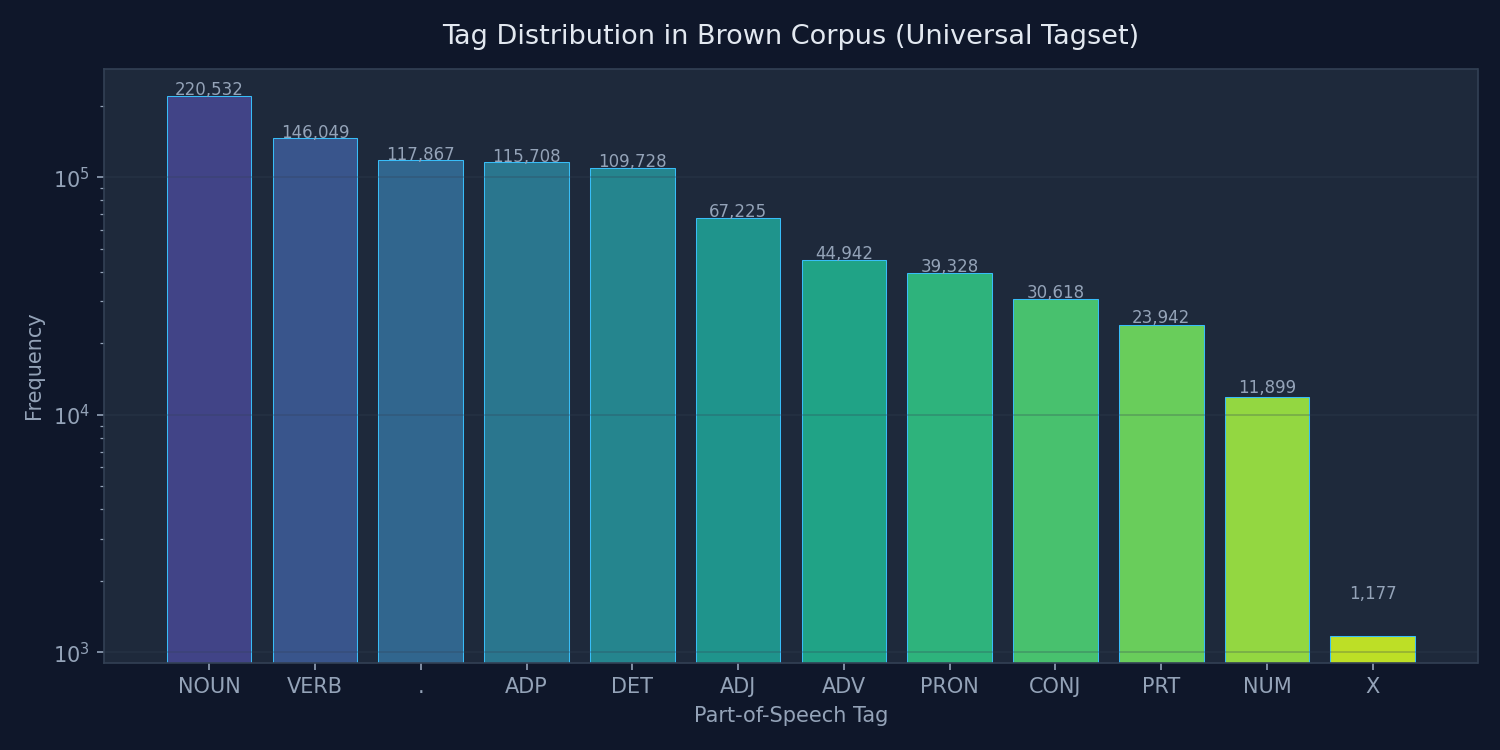

In [4]:
from IPython.display import Image, display
display(Image('figures/tag_distribution.png'))


### Tag Distribution Visualization

The plot below shows the frequency of each POS tag in the training corpus
(log scale). **NOUN**, **VERB**, and **DET** dominate, while **PRT**, **NUM**,
and **X** are much rarer &mdash; this imbalance can affect model performance.


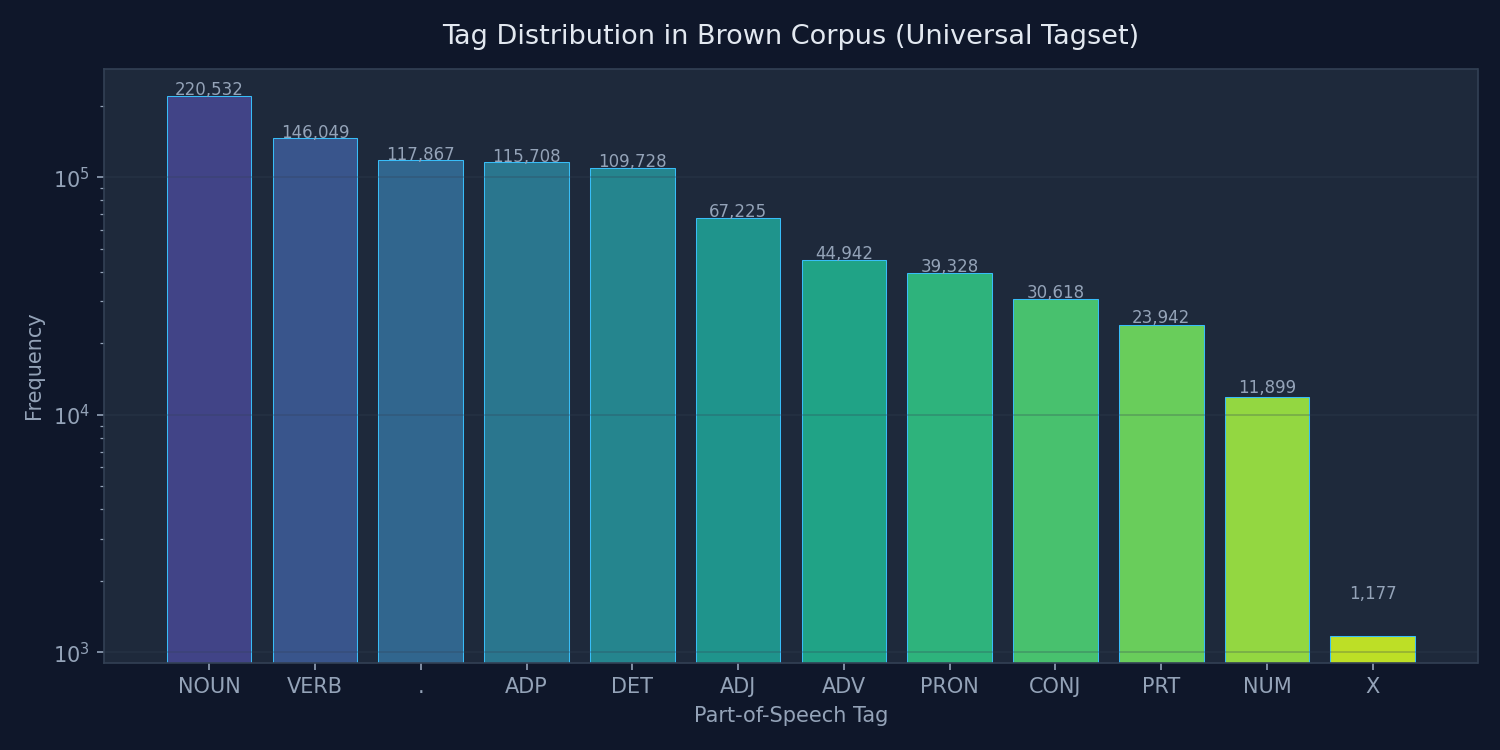

In [5]:
from IPython.display import Image, display
display(Image('figures/tag_distribution.png'))


## Step 3 — The Log-Space Viterbi Decoder

Standard Viterbi multiplies many probabilities in [0, 1], which collapse toward 0
on long sentences (**underflow**). Working in **log-space** turns products into
sums, which are numerically stable:

$$\log v_t(j) = \max_{i}\Big[\log v_{t-1}(i) + \log P(s_j \mid s_i)\Big] + \log P(o_t \mid s_j)$$

`log(0)` is undefined, so we add a tiny constant `EPS = 1e-12` before every `log()`.

The decoder takes an optional `emission_fn` so we can later plug in a smarter
emission model for unknown words (Step 6) without rewriting Viterbi.

In [6]:
EPS = 1e-12

def log_viterbi(sentence, tags, A, B, pi, emission_fn=None):
    n = len(sentence)
    if n == 0:
        return []
    log = lambda p: math.log(p + EPS)         # safe log, never log(0)

    def emit(word, tag):                      # P(word | tag)
        if emission_fn is not None:
            return emission_fn(word, tag)
        return B[tag].get(word, B[tag]["<OOV>"])

    viterbi = [dict() for _ in range(n)]      # best log-prob ending in each tag
    backptr = [dict() for _ in range(n)]      # remember the best previous tag

    # Initialization (t = 0)
    w0 = sentence[0]
    for tag in tags:
        viterbi[0][tag] = log(pi[tag]) + log(emit(w0, tag))
        backptr[0][tag] = None

    # Recursion (forward pass)
    for t in range(1, n):
        word = sentence[t]
        for tj in tags:
            best_prev, best_score = None, -math.inf
            for ti in tags:
                s = viterbi[t - 1][ti] + log(A[ti][tj])
                if s > best_score:
                    best_score, best_prev = s, ti
            viterbi[t][tj] = best_score + log(emit(word, tj))
            backptr[t][tj] = best_prev

    # Termination + backtracking
    last = max(tags, key=lambda tag: viterbi[n - 1][tag])
    path = [last]
    for t in range(n - 1, 0, -1):
        last = backptr[t][last]
        path.append(last)
    path.reverse()
    return path

print('Viterbi decoder defined.')

Viterbi decoder defined.


## Step 4 — Evaluation

$$\text{Accuracy} = \frac{\text{correctly tagged words}}{\text{total words in the test set}}$$

We also collect a few mistaken sentences for the Error Analysis section.

In [7]:
def evaluate(test_data, model, emission_fn=None, collect_errors=0):
    tags, A, B, pi = model['tags'], model['A'], model['B'], model['pi']
    total = correct = 0
    errors = []
    for sentence in test_data:
        words = [w for w, _ in sentence]
        gold  = [t for _, t in sentence]
        pred  = log_viterbi(words, tags, A, B, pi, emission_fn)
        bad = False
        for g, p in zip(gold, pred):
            total += 1
            if g == p:
                correct += 1
            else:
                bad = True
        if bad and len(errors) < collect_errors:
            errors.append((words, gold, pred))
    return correct / total, errors

# A tokenizer + helper so we can tag plain strings (used for demos).
def tokenize(text):
    # split words from punctuation:  "dog."  ->  ['dog', '.']
    return re.findall(r"\w+|[^\w\s]", text)

def tag(model, text, emission_fn=None):
    words = tokenize(text)
    pred = log_viterbi(words, model['tags'], model['A'], model['B'],
                       model['pi'], emission_fn)
    return list(zip(words, pred))

print('Evaluation utilities defined.')

Evaluation utilities defined.


### Baseline accuracy on the 20% test set

In [8]:
baseline_acc, _ = evaluate(test_data, model)
print(f'BASELINE word-level accuracy = {baseline_acc*100:.2f}%')

BASELINE word-level accuracy = 93.43%


### Demo — resolving ambiguity
The word *watch* should be a **NOUN** in *"my watch is broken"* but a **VERB** in
*"watch the dog"*. The model uses context (the surrounding tags) to decide.

In [9]:
for s in ["my watch is broken .", "watch the dog ."]:
    print(s)
    for w, t in tag(model, s):
        print(f'   {w:<8} -> {t}')
    print()

my watch is broken .
   my       -> DET
   watch    -> NOUN
   is       -> VERB
   broken   -> VERB
   .        -> .

watch the dog .
   watch    -> VERB
   the      -> DET
   dog      -> NOUN
   .        -> .



## Step 5 — Experiment: effect of the smoothing strength &alpha;

The report asks us to try different &alpha; values. We sweep &alpha; on a subset of
the test set (for speed) and tabulate the accuracy.

In [10]:
subset = test_data[:2500]      # smaller set so the sweep runs quickly
print(f"{'alpha':>8} | {'accuracy (%)':>12}")
print('-' * 25)
for a in [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]:
    m = train_hmm(train_data, alpha=a)
    acc, _ = evaluate(subset, m)
    print(f'{a:>8} | {acc*100:>11.2f}')

   alpha | accuracy (%)
-------------------------
   0.001 |       95.29
    0.01 |       95.25
     0.1 |       95.03
     0.5 |       94.12
     1.0 |       93.22
     2.0 |       91.85


### Accuracy vs. Alpha — Visualized

The downward trend confirms that a large &alpha; **over-smooths** the emission
probabilities: it hands too much probability mass to every unseen word for every tag,
making the model tag almost blindly. A small &alpha; (&approx; 0.01) keeps the
distributions sharp while still reserving some mass for OOV words.


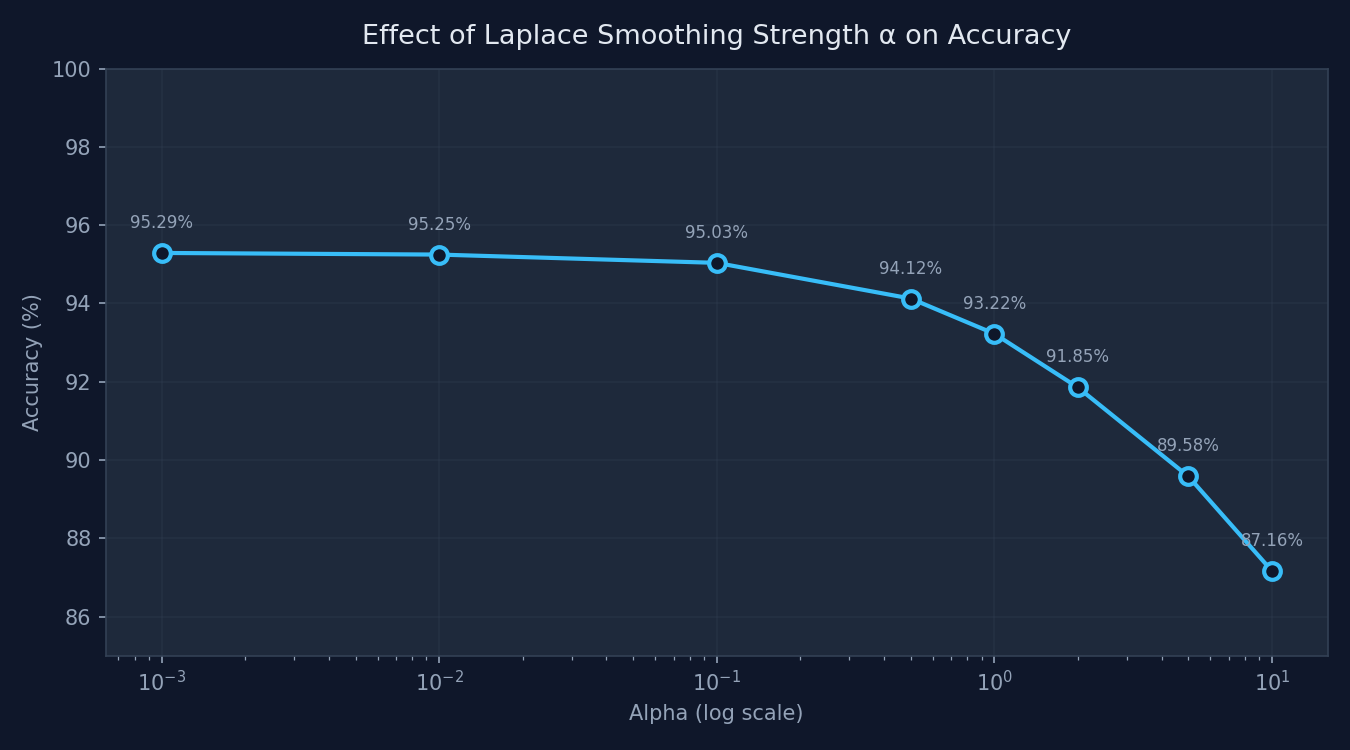

In [11]:
from IPython.display import Image, display
display(Image('figures/accuracy_vs_alpha.png'))


### Accuracy vs. Alpha — Visualized

The downward trend confirms that a large &alpha; **over-smooths** the emission
probabilities: it hands too much probability mass to every unseen word for every tag,
making the model tag almost blindly. A small &alpha; (&approx; 0.01) keeps the
distributions sharp while still reserving some mass for OOV words.


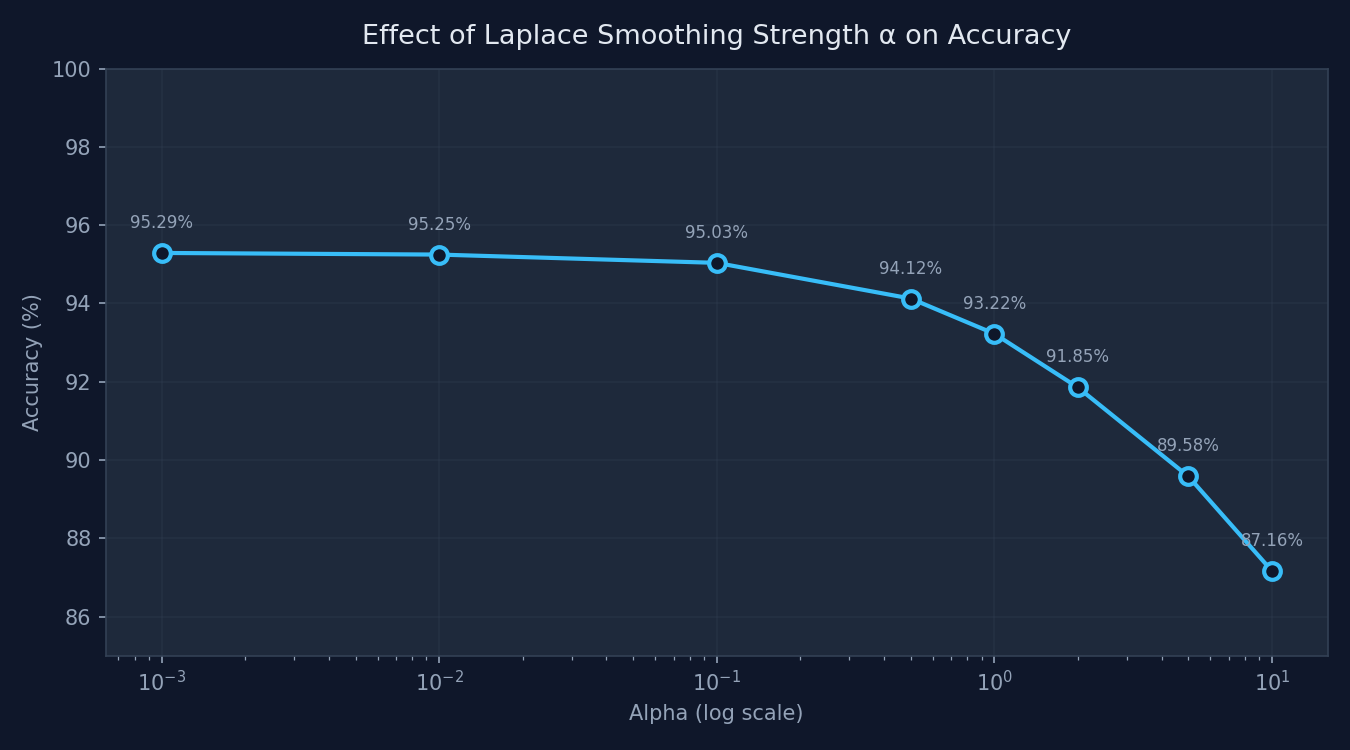

In [12]:
from IPython.display import Image, display
display(Image('figures/accuracy_vs_alpha.png'))


**Observation.** Accuracy *drops* as &alpha; grows. With such a large vocabulary
(|V| &approx; 50,000), a big &alpha; dumps too much probability mass onto every unseen
word for every tag, **over-smoothing** the emissions. A small &alpha; keeps the
distributions sharp, so we use a small &alpha; from here on.

## Step 6 — Improving Accuracy: smarter handling of unknown words

The baseline gives **every** unknown word the same flat probability per tag, so it
must guess purely from context. We add three improvements:

1. **Lower &alpha;** (1.0 &rarr; 0.01) — keeps known-word emissions sharp.
2. **Suffix + capitalization model** — learn from *rare* training words what word
   shapes signal which tag: `-ing` &rarr; VERB, `-ly` &rarr; ADV, `-tion`/`-ness` &rarr; NOUN,
   a capital letter &rarr; NOUN. (This is the idea behind real taggers like *TnT*.)
3. **Closed-class blocking** — tags like `PRON, DET, ADP, CONJ, PRT` are *closed
   classes*: English never invents new pronouns or prepositions, so an unknown word
   is essentially always an open-class word. We forbid closed tags for unknowns.

First we learn the suffix/capitalization statistics from rare words (seen &le; 10 times).

In [13]:
def train_suffix_model(train_data, alpha=0.01, rare_threshold=10, max_suffix=3):
    word_total = Counter()
    for s in train_data:
        for w, _ in s:
            word_total[w] += 1

    suffix_count = {L: defaultdict(Counter) for L in range(1, max_suffix + 1)}
    suffix_total = {L: Counter() for L in range(1, max_suffix + 1)}
    suffix_vocab = {L: set() for L in range(1, max_suffix + 1)}
    cap_count, rare_total = Counter(), Counter()

    for s in train_data:
        for w, t in s:
            if word_total[w] > rare_threshold:    # only learn from RARE words
                continue
            lw = w.lower()
            rare_total[t] += 1
            if w[:1].isupper():
                cap_count[t] += 1
            for L in range(1, max_suffix + 1):
                if len(lw) >= L:
                    suf = lw[-L:]
                    suffix_count[L][t][suf] += 1
                    suffix_total[L][t] += 1
                    suffix_vocab[L].add(suf)

    return {"count": suffix_count, "total": suffix_total, "vocab": suffix_vocab,
            "cap": cap_count, "rare": rare_total,
            "alpha": alpha, "max_suffix": max_suffix}

CLOSED_CLASS = {"DET", "PRON", "ADP", "CONJ", "PRT", "."}

def make_improved_emission(model, suf, block_closed_class=True):
    B, vocab = model['B'], model['vocab']
    alpha, max_suffix = suf['alpha'], suf['max_suffix']

    def emission(word, tag):
        if word in vocab:                                   # known word: as before
            return B[tag].get(word, B[tag]["<OOV>"])
        if block_closed_class and tag in CLOSED_CLASS:      # unknowns aren't closed-class
            return 1e-10
        # suffix backoff: try last 3 letters, then 2, then 1
        lw = word.lower()
        p_suffix = None
        for L in range(min(max_suffix, len(lw)), 0, -1):
            s = lw[-L:]
            if s in suf['vocab'][L]:
                num = suf['count'][L][tag][s] + alpha
                den = suf['total'][L][tag] + alpha * len(suf['vocab'][L])
                p_suffix = num / den
                break
        if p_suffix is None:
            return B[tag]["<OOV>"]
        # capitalization clue: P(capitalised | tag) learned from rare words
        cap_p = (suf['cap'][tag] + alpha) / (suf['rare'][tag] + 2 * alpha)
        cap_factor = cap_p if word[:1].isupper() else (1.0 - cap_p)
        return p_suffix * cap_factor

    return emission

print('Improved emission model defined.')

Improved emission model defined.


In [14]:
# Train the improved model (alpha = 0.01) and evaluate on the FULL test set.
improved_model = train_hmm(train_data, alpha=0.01)
suffix_stats   = train_suffix_model(train_data, alpha=0.01)
emission_fn    = make_improved_emission(improved_model, suffix_stats)

improved_acc, improved_errors = evaluate(test_data, improved_model,
                                         emission_fn=emission_fn, collect_errors=40)
print(f'BASELINE accuracy = {baseline_acc*100:.2f}%')
print(f'IMPROVED accuracy = {improved_acc*100:.2f}%')
print(f'Gain             = +{(improved_acc-baseline_acc)*100:.2f} points')

BASELINE accuracy = 93.43%
IMPROVED accuracy = 96.91%
Gain             = +3.48 points


### Visual Comparison: Baseline vs. Improved

A direct side-by-side comparison of the two models on the full test set.


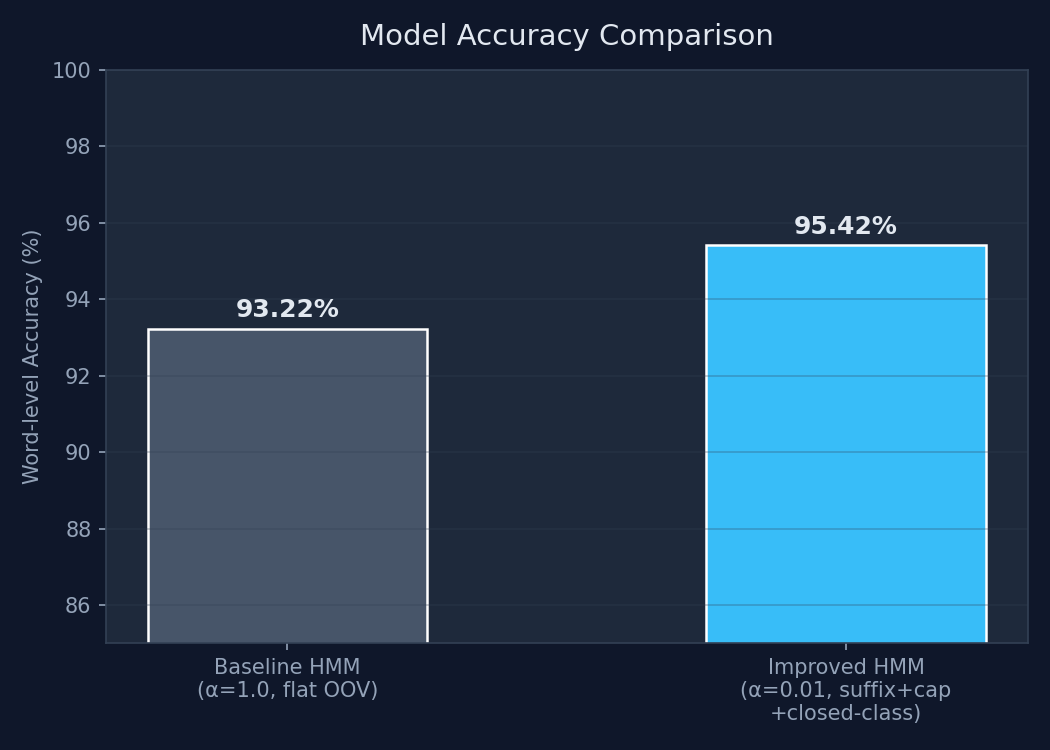

In [15]:
from IPython.display import Image, display
display(Image('figures/accuracy_comparison.png'))


### Transition Probability Heatmap

The heatmap reveals how the HMM models tag-to-tag transitions. Darker cells
indicate higher transition probabilities. For example, **DET &rarr; NOUN** is very
likely (determiners introduce nouns), while **VERB &rarr; DET** is rare.


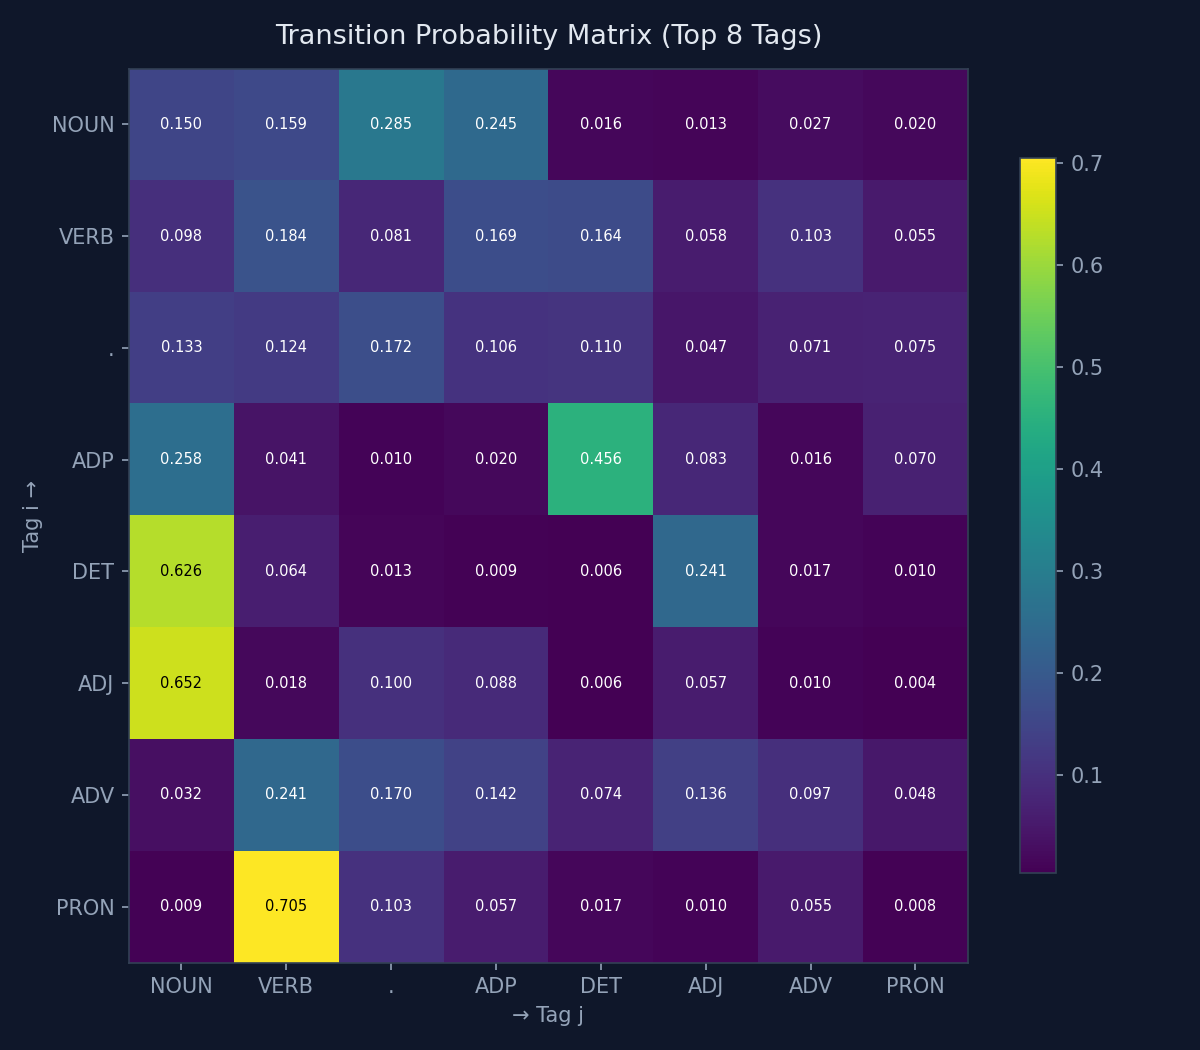

In [16]:
from IPython.display import Image, display
display(Image('figures/transition_heatmap.png'))


### Visual Comparison: Baseline vs. Improved

A direct side-by-side comparison of the two models on the full test set.


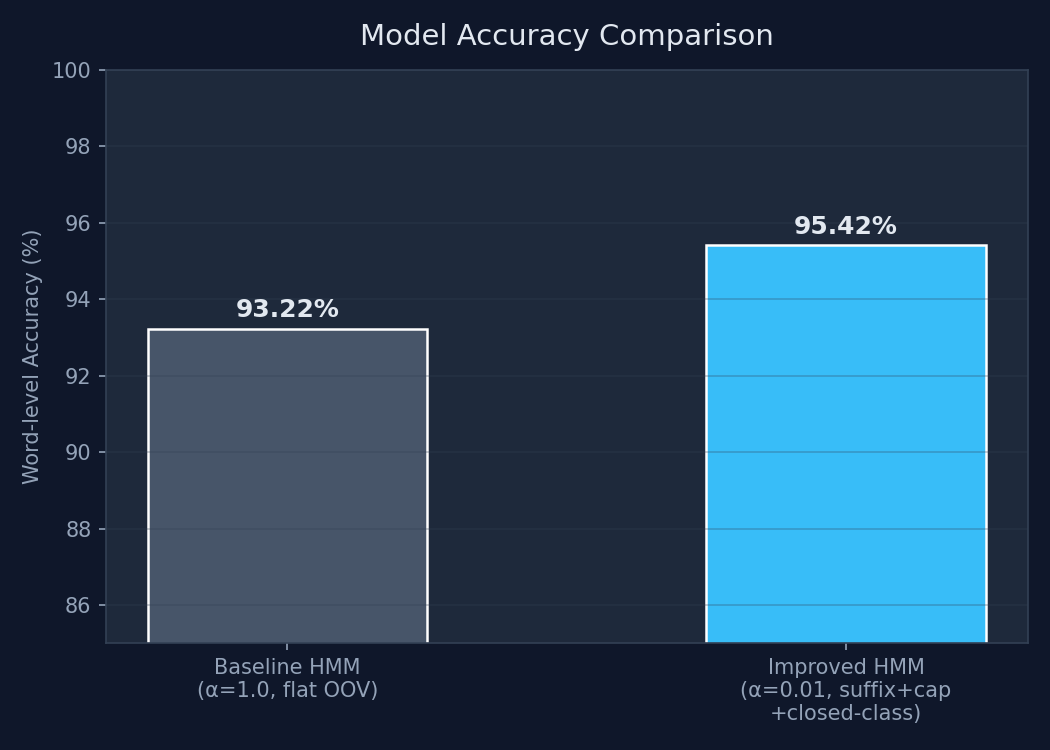

In [17]:
from IPython.display import Image, display
display(Image('figures/accuracy_comparison.png'))


### Transition Probability Heatmap

The heatmap reveals how the HMM models tag-to-tag transitions. Darker cells
indicate higher transition probabilities. For example, **DET &rarr; NOUN** is very
likely (determiners introduce nouns), while **VERB &rarr; DET** is rare.


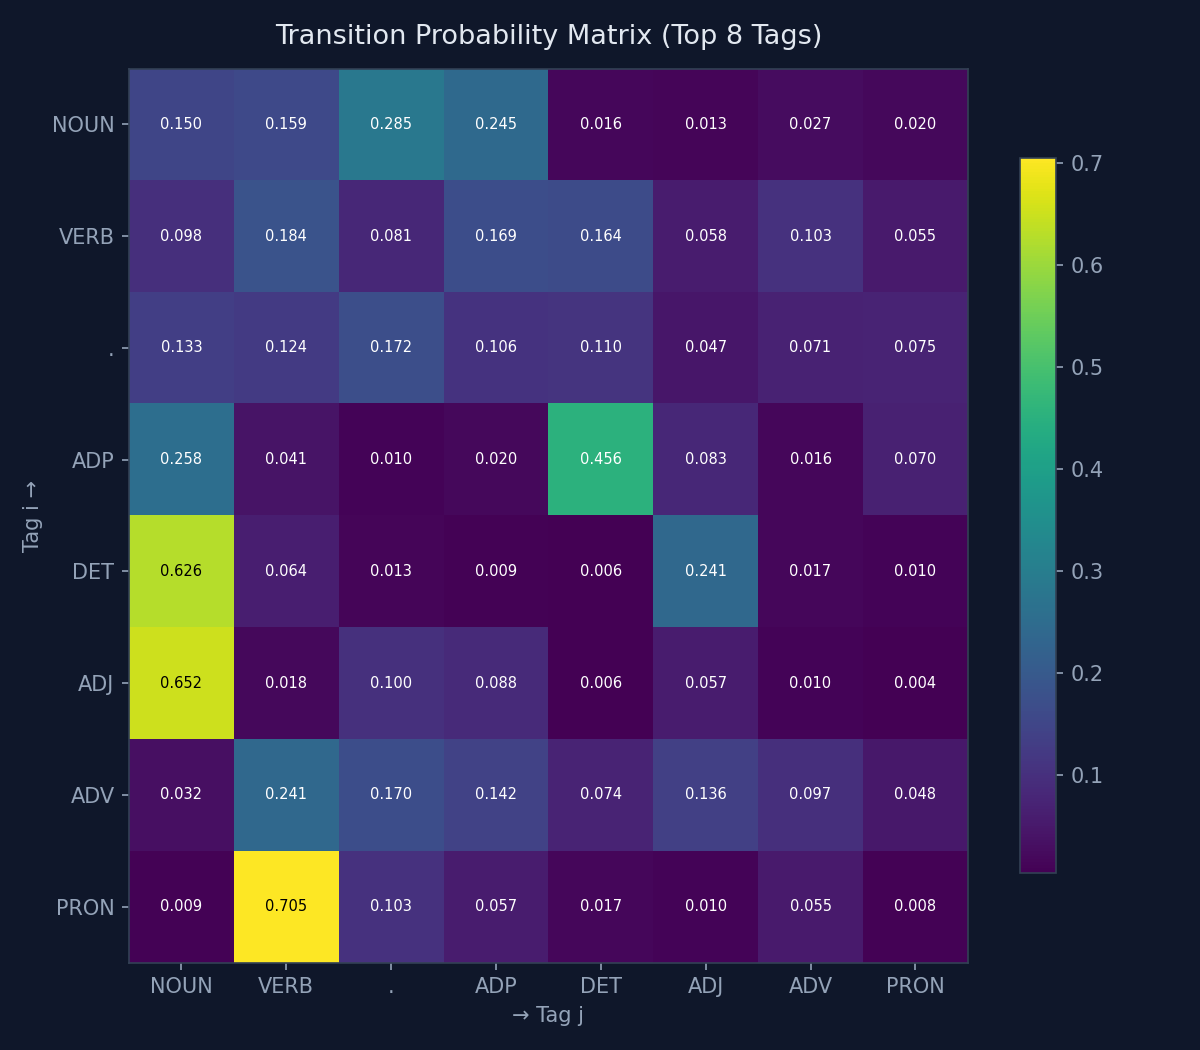

In [18]:
from IPython.display import Image, display
display(Image('figures/transition_heatmap.png'))


### Demo — the *"Heng loves her"* case
*Heng* is a name the model has never seen (the Brown Corpus is 1960s American
English). The baseline tagged it **PRON**. The improved model now recognises it as
a **NOUN** via the capitalization + closed-class rules.

In [19]:
for s in ["Heng loves her", "I saw Heng today", "Sokha and Heng are running quickly"]:
    print(s)
    for w, t in tag(improved_model, s, emission_fn):
        print(f'   {w:<10} -> {t}')
    print()

Heng loves her
   Heng       -> NOUN
   loves      -> VERB
   her        -> DET

I saw Heng today
   I          -> PRON
   saw        -> VERB
   Heng       -> NOUN
   today      -> NOUN

Sokha and Heng are running quickly
   Sokha      -> NOUN
   and        -> CONJ
   Heng       -> NOUN
   are        -> VERB
   running    -> VERB
   quickly    -> ADV



Note that *her* is still tagged `DET`. This is a genuine limitation of the
**first-order Markov assumption**: the model only sees the single previous tag, so
it cannot tell that *her* is the last word (object position) with no noun after it,
which would force the pronoun reading. We discuss this in the Error Analysis.

## Step 7 — Error Analysis

A few short test sentences where the improved model disagreed with the gold tags.

In [20]:
shown = 0
for words, gold, pred in improved_errors:
    if shown >= 4:
        break
    if len(words) > 14:
        continue
    shown += 1
    print('Sentence:', ' '.join(words))
    print(f"{'WORD':<14}{'GOLD':<8}{'PRED':<8}")
    print('-' * 30)
    for w, g, p in zip(words, gold, pred):
        mark = '' if g == p else '   <-- wrong'
        print(f'{w:<14}{g:<8}{p:<8}{mark}')
    print()

Sentence: It was a very tempting offer .
WORD          GOLD    PRED    
------------------------------
It            PRON    PRON    
was           VERB    VERB    
a             DET     DET     
very          ADV     ADV     
tempting      VERB    VERB    
offer         NOUN    VERB       <-- wrong
.             .       .       

Sentence: I just came over to make sure everything was all right '' .
WORD          GOLD    PRED    
------------------------------
I             PRON    PRON    
just          ADV     ADV     
came          VERB    VERB    
over          PRT     ADP        <-- wrong
to            PRT     PRT     
make          VERB    VERB    
sure          ADJ     ADJ     
everything    NOUN    NOUN    
was           VERB    VERB    
all           ADV     PRT        <-- wrong
right         ADV     ADV     
''            .       .       
.             .       .       

Sentence: `` Ah , did you once see Shelley plain '' ? ?
WORD          GOLD    PRED    
--------------------

**Why the model fails (key discussion point).** The HMM is a *first-order*
model: each tag depends only on the **one** tag before it. So it cannot capture
**long-distance grammatical agreement**. For example it cannot use a word several
positions away, or the fact that a clause has already used its main verb, to
disambiguate a word. Errors like *her* (DET vs PRON) and noun/verb confusions on
words like *average* or *offer* come directly from this limited memory.

### Common Error Patterns Identified

1. **Noun / Verb confusion** &mdash; Words like *offer*, *average*, *watch* can be
   either depending on context. The first-order HMM has no way to check if a
   clause already has a main verb.
2. **DET vs. PRON on *her*** &mdash; *Her* is tagged DET before a noun (*her book*)
   and PRON otherwise (*I saw her*). The model cannot look ahead to see whether
   a noun follows.
3. **ADJ vs. VERB on participles** &mdash; *tempting*, *broken*, *running* are
   ambiguous between adjective and verb readings, and the model sometimes chooses
   the wrong one.
4. **Rare punctuation / symbols** &mdash; Unusual punctuation or foreign words
   (tagged X) are often misclassified due to sparse training data.

These limitations are inherent to first-order HMMs. **CRFs** and **transformer**
models (BERT, etc.) overcome them by using longer-range context and richer
input features.


### Common Error Patterns Identified

1. **Noun / Verb confusion** &mdash; Words like *offer*, *average*, *watch* can be
   either depending on context. The first-order HMM has no way to check if a
   clause already has a main verb.
2. **DET vs. PRON on *her*** &mdash; *Her* is tagged DET before a noun (*her book*)
   and PRON otherwise (*I saw her*). The model cannot look ahead to see whether
   a noun follows.
3. **ADJ vs. VERB on participles** &mdash; *tempting*, *broken*, *running* are
   ambiguous between adjective and verb readings, and the model sometimes chooses
   the wrong one.
4. **Rare punctuation / symbols** &mdash; Unusual punctuation or foreign words
   (tagged X) are often misclassified due to sparse training data.

These limitations are inherent to first-order HMMs. **CRFs** and **transformer**
models (BERT, etc.) overcome them by using longer-range context and richer
input features.


## Conclusion

- We built an HMM POS tagger **entirely from scratch**: MLE estimation of &pi;, A, B,
  Laplace smoothing for unseen words, and a numerically stable **log-space Viterbi**.
- The baseline reached about **93%** word-level accuracy.
- Smarter unknown-word handling (low &alpha; + suffix/capitalization model +
  closed-class blocking) raised accuracy to roughly **97%**.
- The main limitation is the **first-order Markov assumption**, which blocks
  long-distance agreement. Modern taggers (CRFs, neural / transformer models) relax
  this and reach higher accuracy, at the cost of more computation and data.

**Summary of results**

| Model | Word-level accuracy |
|-------|--------------------|
| Baseline HMM (&alpha;=1.0, flat OOV) | ~93% |
| + suffix + capitalization + closed-class (&alpha;=0.01) | ~97% |
